<a href="https://colab.research.google.com/github/Cygus314i/Exploratory-Data-Analysis-Beginner-level-to-learn-/blob/main/Gaming%26Academic_performances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import  seaborn as sns

In [10]:
df = pd.read_csv("/Gaming_Hours_vs_Performance_1000_Rows.csv")
columns = df.columns
print(columns)
df.describe()

Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Game_Type',
       'Daily_Gaming_Hours', 'Weekly_Gaming_Hours', 'Primary_Gaming_Time',
       'Sleep_Hours', 'Stress_Level', 'Focus_Level', 'Academic_or_Work_Score',
       'Productivity_Level', 'Performance_Impact'],
      dtype='object')


,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,26.600000,3.320300,23.242100,6.479500,5.454000,6.065000,75.07800,75.275000
std,5.207218,1.613059,11.291414,1.155848,2.281905,2.010178,11.67494,12.058805
min,18.000000,0.500000,3.500000,4.500000,2.000000,3.000000,55.00000,50.000000
25%,22.000000,2.000000,14.000000,5.475000,3.000000,4.000000,65.00000,65.000000
50%,27.000000,3.300000,23.100000,6.500000,5.000000,6.000000,75.00000,75.000000
75%,31.000000,4.800000,33.600000,7.500000,7.000000,8.000000,85.00000,86.000000
max,35.000000,6.000000,42.000000,8.500000,9.000000,9.000000,95.00000,100.000000


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
df_age = df[df["Age"] < 23].copy()

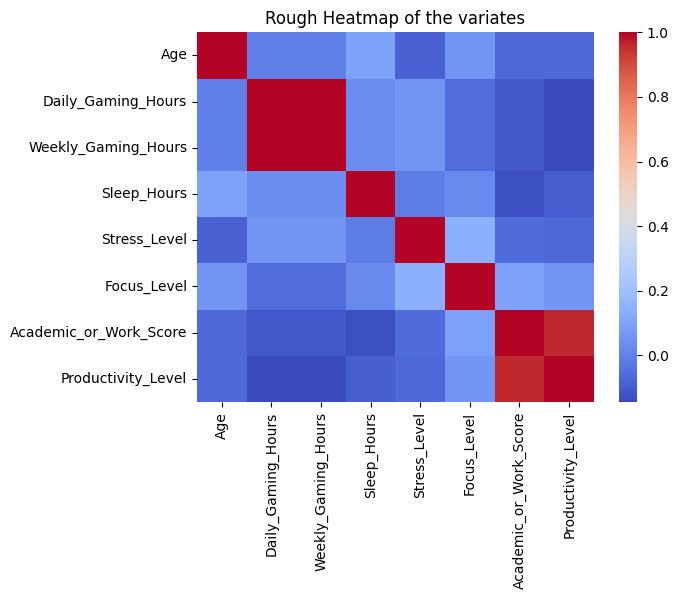

In [13]:
corr_matrix = df_age.corr(numeric_only=True)

sns.heatmap(corr_matrix,cmap = "coolwarm")
plt.title("Rough Heatmap of the variates")
plt.show()

Here we can see that most variates basically have no correlation (daily and weekly gaming hours is basically pointless) but we see that productivity level and academic score show a correlation . So i will be performing bi variate analysis on them first

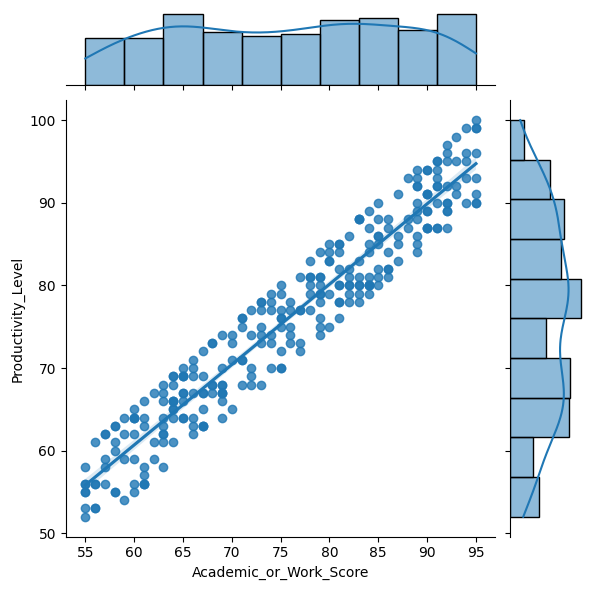

In [17]:
sns.jointplot(df_age,x=df_age["Academic_or_Work_Score"], y = df_age["Productivity_Level"],kind="reg")
plt.show()

we clearly see a positive correlation between the academic score and productivity level soooo i am going to check if any variable affects the productivity level so we can relate those together and come to a meaning ful conclusion

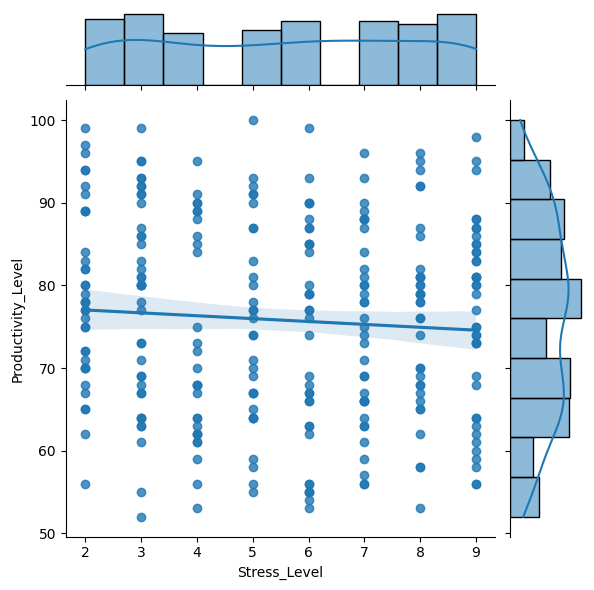

In [28]:
sns.jointplot(df_age,y =df_age["Productivity_Level"], x = df_age["Stress_Level"],kind="reg")
plt.show()

My initial thought was the relation between stress level and productivity but from the regression and best line fit graph we observe basically no relation

Now i check the gaming hours and productivity level so see any relation between them

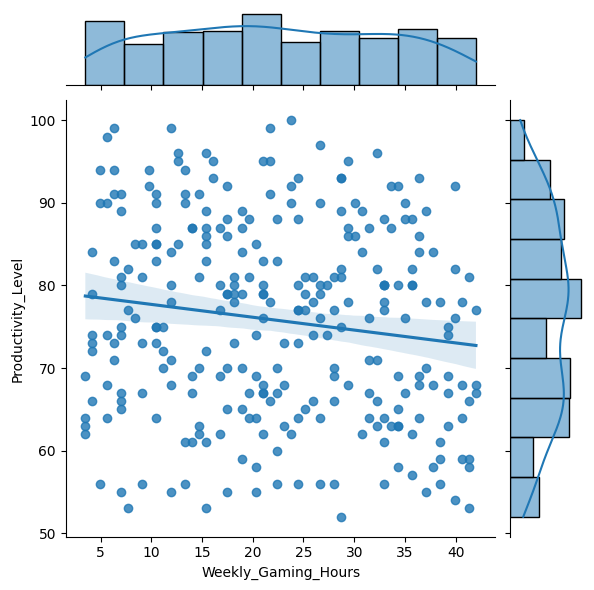

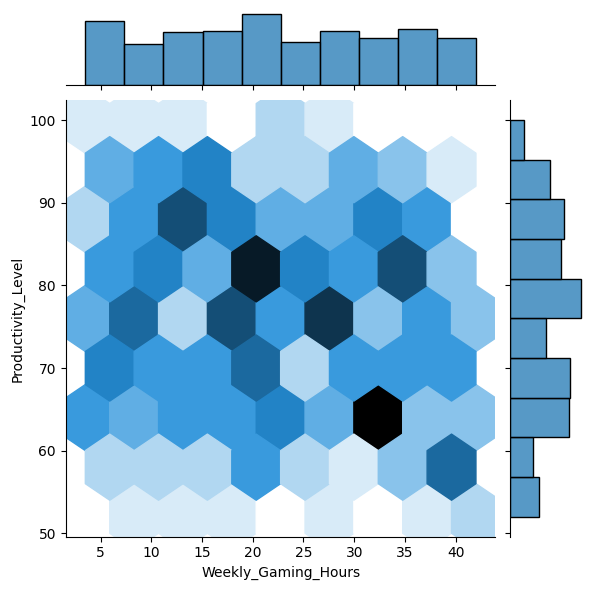

In [30]:
sns.jointplot(df_age,x=df_age["Weekly_Gaming_Hours"], y = df_age["Productivity_Level"],kind="reg")
sns.jointplot(df_age,x=df_age["Weekly_Gaming_Hours"], y = df_age["Productivity_Level"],kind="hex")
plt.show()

The best fit line didnt show any actual relationship so i tried a hex map to see if any specific range has a density but it shows no insights to me

Since i am not finding a good relationships so i move to categories of the games and their respective productivity and scores

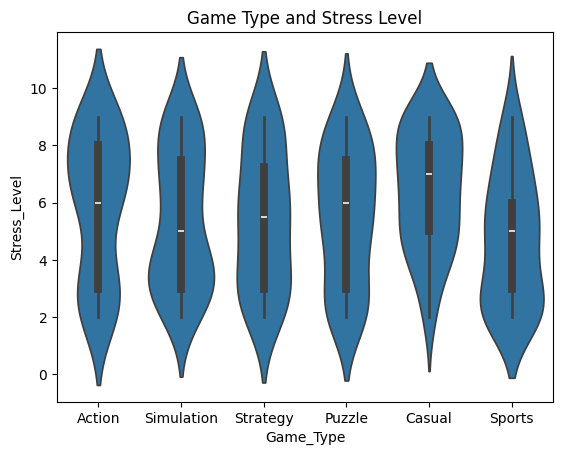

In [15]:
sns.violinplot(df_age,x=df_age["Game_Type"], y = df_age["Stress_Level"])
plt.title("Game Type and Stress Level")
plt.show()

We see that each genre has the follopwing median density related to stress:
Action = 8
Simulation = 3.5
Strategy = 3
Puzzle = 6
Casual = 7
Sports = 2

Now I take each genre and see the academics scores
also by this way we can see if each genre can influence each variables and vice versa

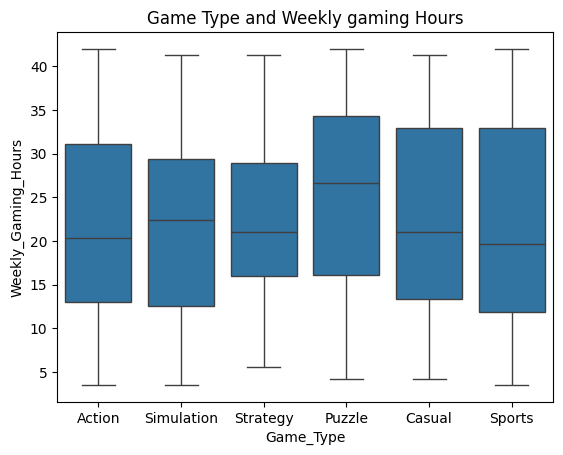

In [16]:
sns.boxplot(df_age,x=df_age["Game_Type"], y = df_age["Weekly_Gaming_Hours"])
plt.title("Game Type and Weekly gaming Hours")
plt.show()

In [ ]:
game_types = [p for p in df_age["Game_Type"].unique()]

In [34]:
df_action = df_age[df_age["Game_Type"] == "Action"].copy()
df_action.head()

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral
23,U0024,19,Female,Student,Action,2.1,14.7,Night,8.4,2,8,75,70,Neutral
28,U0029,21,Male,Working Professional,Action,2.2,15.4,Morning,8.4,2,8,90,89,Neutral
67,U0068,22,Female,Student,Action,4.4,30.8,Night,5.0,2,3,90,89,Negative
